# Land-use lab — world building and sensor signal probing

Two questions, in order.

1. **Does a land-use drift reach the water?** Build one world for a chosen network and
   an init/final consumption map, and check that the demand change shows up in pressure
   and flow — not just in the demand series that nothing downstream ever sees.
2. **Which gauges carry it?** Rank every junction (pressure) and every link (flow) by how
   well its weekly signature reproduces its own district's demand signature, before and
   after the drift. That ranking is the input to sensor placement, and therefore to
   whether a federated prototype can carry regime information at all.

Engines: `landuse_world.py` (build + persist) and `signal_probe.py` (analysis). Neither
re-implements anything in `src/` — `landuse_world` calls the shipped `fedwater.pipelines.*`
nodes in `__default__` order, with the parameters assembled in Python so the network is an
argument instead of a line in `conf/base/globals.yml`.

Out of scope this round: the drift engine and the FL stack. `landuse_engine.py` is
superseded — its three overrides (`build_portfolios`, `evolve_assignments`,
`synthesize_demands`) now exist in `src/` with natural-sorted node order, `stable_hash`
keying and the network-scoped resolver, none of which the override had.

## 0. Setup

In [1]:
%matplotlib inline
import sys, warnings, pathlib, json
import numpy as np, pandas as pd, matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 200, "display.max_columns", 60)

HERE = pathlib.Path.cwd()
ROOT = next(p for p in [HERE, *HERE.parents] if (p / "conf" / "base").exists())
for p in (HERE, ROOT / "src", ROOT):           # engines, fedwater, fedwater_lab
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

import landuse_world as lw
import signal_probe as sp

OUT = ROOT / "data" / "09_experiments" / "landuse_probe"
OUT.mkdir(parents=True, exist_ok=True)
print(ROOT, "|", lw.ANCHOR_SCALE)

c:\Users\arthu\USPy\10_Mestrado\fedWater | {'graeme': 0.05, 'ky7': 0.5, 'dtown': 0.25}


## 1. Configuration

One dict per network. `map_code` is the **initial** state, positional over districts in
name order; `tgt_district` + `to_land_use` is the **final** state of the one district that
moves. `anchor_scale` is hardcoded per network in `landuse_world.ANCHOR_SCALE` and passed
explicitly, so `resolve_params` finds nothing to fill and the bundle's value is bypassed
rather than fought with.

Horizon note: `days_per_month = 28` keeps four whole weeks per month, so a monthly weekly
profile is balanced. `warmup_months = 2` puts the first switch at month 2, which makes the
label-clean `init` phase months 0–1.

In [2]:
CFGS = {
    "ky7": lw.WorldCfg(
        network="ky7",
        map_code="LR_LI_LR_LR",          # 4 districts: B starts commercial
        tgt_district="District_A",
        to_income="low", to_land_use="industrial",
        beta=0.35, n_months=50, days_per_month=28, warmup_months=6,
        drift_ramp_days=14, seasonality_scale=0.0),
    "dtown": lw.WorldCfg(
        network="dtown",
        map_code="LR_LI_LR_LR_LR",       # 5 districts: B starts commercial
        tgt_district="District_E",
        to_income="low", to_land_use="industrial",
        beta=0.35, n_months=36, days_per_month=14, warmup_months=2,
        max_neighbors_per_month = 8,
        drift_ramp_days=2, seasonality_scale=0.0),
}

NETWORK = "dtown"        # <<< the POC switch
CFG = CFGS[NETWORK]
CFG

WorldCfg(network='dtown', map_code='LR_LI_LR_LR_LR', tgt_district='District_E', to_income='low', to_land_use='industrial', seed_node=None, beta=0.35, anchor_scale=None, coupling_variant='baseline', close_fraction=0.5, n_months=36, days_per_month=14, resolution_h=1, warmup_months=2, seed=42, growth_chance=None, max_neighbors_per_month=8, drift_ramp_days=2, seasonality_scale=0.0, extra={})

Two deliberate choices in those configs.

**A second commercial district at t0.** With every district on `LR`, "which district does
this sensor look like" has no answer — the demand model gives them the same signature by
construction, so any hit rate is chance. `District_B` starts `LC` so there is a real
regime contrast before the drift, and the post-drift state has two.

**`seasonality_scale = 0.0`.** The init and final phases sit at different points of the
seasonal cycle; leaving seasonality on adds a level swing to every before/after comparison
that has nothing to do with land use. Turn it back on once the shape result is established.

## 2. Build the world

In [3]:
world = lw.build(CFG, ROOT)
path = lw.persist(world, OUT)
print("\nworld written to", path)

c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\wntr\epanet\io.py:2082: UserWarning: Not all curves were used in "c:\Users\arthu\USPy\10_Mestrado\fedWater\data\01_raw\dtown\network.inp"; added with type None, units conversion left to user
  warnings.warn('Not all curves were used in "{}"; added with type None, units conversion left to user'.format(self.wn.name))


configure_network: 7 tank(s), 11 pump(s) [HEAD:11], 5 valve(s), 24 control(s) are active in this model.
[dtown] solving 12,096 steps x 348 nodes ...
run_hydraulics: 51 junction(s) carry no portfolio and were pinned to zero demand (e.g. ['J415', 'J416', 'J418', 'J419', 'J420']).
sim_hash                           58b05e29
network                               dtown
map                          LR_LI_LR_LR_LR
drift                District_E->industrial
beta                                   0.35
anchor                                 0.25
months                                   36
steps                                 12096
mean_lps                              126.7
peak_lps                              218.5
pmin                                  16.68
pmax                                 121.65
in_band_%                             100.0
drifted_nodes                       149/149
switch_months                         2..31
validation_failed                         -
seconds          

In [4]:
rep = world["reports"]["validation"]
display(rep[~rep["passed"]] if (~rep["passed"]).any() else "all validation checks passed")
rep[rep["check"].str.startswith(("V1_", "V2_", "V3_", "V4_", "V8_tank_floor"))].round(6)

'all validation checks passed'

,check,value,hard,passed
0,V1_mass_balance,0.000000,True,True
4,V2_volume_exactness,0.000002,True,True
5,V3_pressure_floor,16.682066,True,True
7,V4_pressure_band_share,1.000000,False,True
8,V8_tank_floor_share[T3],0.000000,False,True
11,V8_tank_floor_share[T1],0.000000,False,True
14,V8_tank_floor_share[T7],0.000000,False,True
17,V8_tank_floor_share[T6],0.000000,False,True
20,V8_tank_floor_share[T5],0.000000,False,True
23,V8_tank_floor_share[T2],0.001405,False,True


The world directory is `manifest.json` + a `clone/` tree that mirrors the catalog paths
exactly, so `fedwater_lab.load_world` reads it with no special case and the FL side gets
its `client_datasets` CSVs where it expects them.

`World.districts_file` is still hardcoded to `01_raw/districts_graeme.yml`; `persist`
writes the partition to that name **and** to `districts.yml` so a non-Graeme world is not
silently partition-less. Worth fixing in `worlds.py` rather than carrying forever.

In [5]:
from worlds import load_world
W = load_world(path)
display(W.summary().to_frame("value"))
print("clients:", sorted(p.name for p in W.clients_dir.glob("*.csv")))
print("client frame:", next(iter(W.clients_dir.glob("*.csv"))).name,
      pd.read_csv(next(iter(W.clients_dir.glob("*.csv")))).shape)

,value
sim_hash,58b05e29
tag,District_E__LR_LI_LR_LR_LR__baseline
n_months,36
resolution_h,1
steps_day,24
clients,5
drift_district,District_E
warmup_months,2
first_switch,2
last_switch,31


clients: ['District_A.csv', 'District_B.csv', 'District_C.csv', 'District_D.csv', 'District_E.csv']
client frame: District_A.csv (12096, 7)


## 3. Ground truth

Before measuring anything: did the land-use map actually reach the demand series?
`template_fit` correlates each district's realised weekly demand profile against the pure
sector signature for the regime it was assigned. A low number means the map is not doing
what the label says, and no sensor ranking downstream can recover what was never there.

In [6]:
P = sp.from_world(world)
print("phases (months, half-open):", P.phases())
print("init regimes :", P.regimes("init"))
print("final regimes:", P.regimes("final"))
display(P.schedule.groupby("drift_month").size().rename("nodes switching").to_frame().T)
sp.template_fit(P).round(3)

phases (months, half-open): {'init': (0, 2), 'final': (32, 36)}
init regimes : {'District_A': 'LR', 'District_B': 'LI', 'District_C': 'LR', 'District_D': 'LR', 'District_E': 'LR'}
final regimes: {'District_A': 'LR', 'District_B': 'LI', 'District_C': 'LR', 'District_D': 'LR', 'District_E': 'LI'}


drift_month,2,3,4,5,6,7,8,10,11,13,14,15,16,17,18,19,20,21,22,24,25,26,27,29,30,31
nodes switching,1,1,2,3,4,4,4,5,7,7,7,5,7,8,8,8,8,8,8,8,8,8,7,5,4,4


,district,phase,regime,r_template
0,District_A,init,low/residential,1.000
1,District_B,init,low/industrial,1.000
2,District_C,init,low/residential,1.000
3,District_D,init,low/residential,0.999
4,District_E,init,low/residential,1.000
5,District_A,final,low/residential,1.000
6,District_B,final,low/industrial,1.000
7,District_C,final,low/residential,1.000
8,District_D,final,low/residential,1.000
9,District_E,final,low/industrial,1.000


## 4. Demand → pressure and flow

What the previous notebook was missing. A district's demand change is only useful if it
reaches a channel the clients observe.

`shape_shift` is `1 - corr` between the z-scored weekly demand profiles of the two phases:
the part of the change that survives a per-client MinMax scaler. `d_pressure` and
`d_boundary_%` say whether it reached an observable. A large `shape_shift` next to a flat
`d_pressure` is a drift that is real and invisible.

`boundary_flow` is NaN for the district that owns the source — all its links to the
reservoir are internal to it, so it has no inter-district crossing to meter.

In [7]:
sp.phase_delta(P)

,district,regime,drifted,demand_init,demand_final,d_demand_%,shape_shift,pressure_init,pressure_final,d_pressure,boundary_flow_init,boundary_flow_final,d_boundary_%
0,District_A,LR->LR,False,24.835,24.859,0.099,0.000,53.579,53.558,-0.021,8.222,8.234,0.148
1,District_B,LI->LI,False,24.271,24.102,-0.698,0.000,45.146,75.253,30.107,12.120,12.051,-0.569
2,District_C,LR->LR,False,13.294,13.220,-0.561,0.000,58.092,58.190,0.099,6.577,6.633,0.849
3,District_D,LR->LR,False,7.689,7.697,0.099,0.001,69.013,69.005,-0.008,7.792,7.633,-2.040
4,District_E,LR->LI,True,35.592,77.133,116.717,0.725,54.526,53.239,-1.288,NaN,NaN,NaN


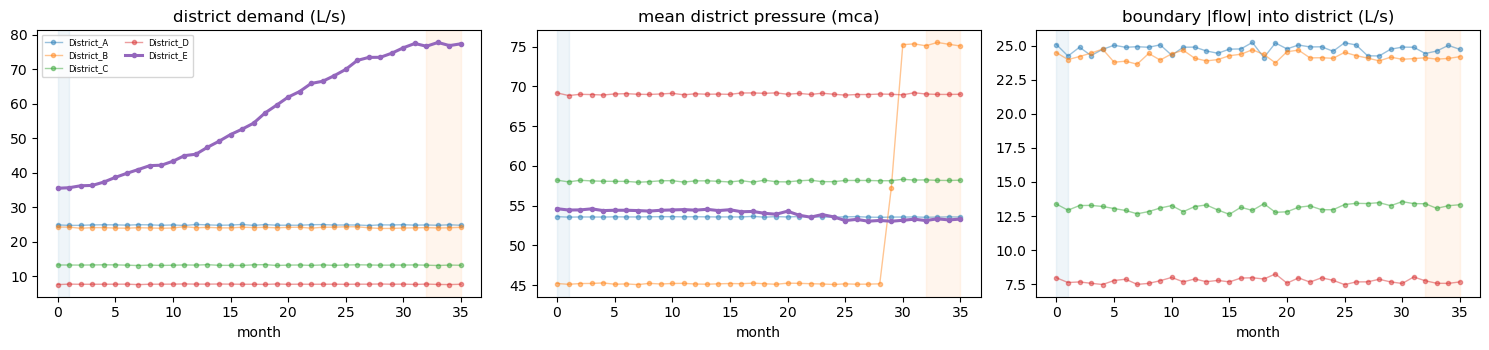

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
sp.plot_district_response(P, axes=axes)
plt.tight_layout(); plt.show()

## 5. Candidate universe

Every junction that carries demand, and every link. Junctions with no demand are dropped:
they have a pressure and no customer behind it, so a gauge there measures the network
rather than a client.

`served_own` is the a-priori prediction — the share of the demand fed *through* this link
that belongs to its own district, computed by cutting the link and walking downstream from
the mean-flow direction. Exact on a tree, an over-count on loops. It is an annotation, not
a score; §9 checks it against what was actually measured.

In [9]:
cand = sp.candidates(P)
display(cand.groupby(["kind", "role"]).size().rename("n").to_frame().T)
print("shipped sensors located:", int(cand['shipped'].sum()),
      "of", sum(len(v.get('pressure', [])) + len(v.get('flow', []))
                for v in P.sensors.values()))
display(cand[cand["kind"] == "flow"].groupby("role")["served_own"]
        .describe()[["count", "mean", "50%", "max"]].round(3))
cand.head()

kind     flow          pressure
role boundary internal internal
n           8      451      348

shipped sensors located: 25 of 25


,count,mean,50%,max
role,,,,
boundary,8.0,0.155,0.190,0.196
internal,443.0,0.543,0.448,1.000


,id,element,kind,district,role,elev,base_demand,served_own,link_type,served_top,from_district,to_district,shipped
0,q_1,1,flow,District_A,internal,NaN,NaN,0.196346,pipe,District_E,District_A,District_A,False
1,q_10,10,flow,District_A,internal,NaN,NaN,0.196346,pipe,District_E,District_A,District_A,False
2,q_11,11,flow,District_A,internal,NaN,NaN,0.196346,pipe,District_E,District_A,District_A,False
3,q_12,12,flow,District_A,internal,NaN,NaN,0.196346,pipe,District_E,District_A,District_A,False
4,q_13,13,flow,District_A,internal,NaN,NaN,0.196346,pipe,District_E,District_A,District_A,False


## 6. The battery

One row per (candidate, phase). Three things the naive version gets wrong, and what is
done about each:

**Common mode.** Everything on a closed network correlates with the aggregate diurnal
cycle, so `r_raw_own` is high nearly everywhere and ranks nothing. `r_res_own` is the same
correlation after projecting the network-total weekly profile out of both series. That is
the number that discriminates.

**Sign.** Pressure is negated; flow is oriented by the sign of its mean. The alignment
applied is recorded in the `sign` column, so nothing is silently flipped.

**Same-regime districts are not separable.** Comparing against a district that carries the
same regime token is not a test of anything. Every "which district does this look like"
statistic therefore comes in two forms — `hit_rate` against districts, `regime_hit_rate`
against regimes — and only the second is a claim about recoverability.

In [10]:
scores = sp.battery(P, cand)
print(scores.shape)
sp.discriminative_gap(scores).round(3)

(1614, 26)


,phase,kind,n,r_res_own,r_res_other_regime,gap_regime,gap,margin_regime,hit_rate,regime_hit_rate,response
0,final,flow,459,0.608,-0.608,1.217,0.733,1.216,0.521,0.856,0.249
1,final,pressure,348,0.338,-0.337,0.675,0.412,0.675,0.437,0.891,0.158
2,init,flow,459,0.457,-0.450,0.907,0.365,0.904,0.368,0.843,0.249
3,init,pressure,348,0.137,-0.135,0.272,0.099,0.271,0.339,0.813,0.158


`gap_regime` = `r_res_own` − mean correlation against districts of a *different* regime.
Its range is [-2, 2], not [-1, 1]: after the common mode is removed, a two-regime world
leaves residuals that are close to exact anti-correlates.

Reference point from Graeme: the discriminative gap was ~0.004 on pressure against ~0.23
on flow, which is why pressure-only placements never separated clients. Reproduce that
comparison here before trusting anything built on this network.

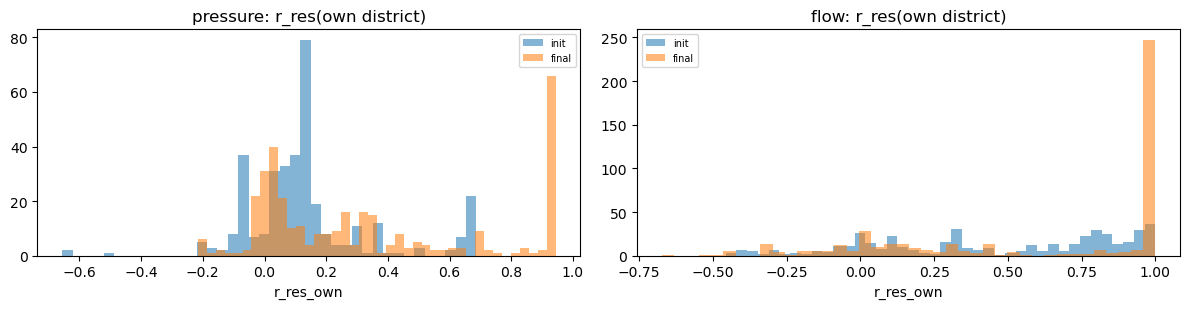

lag structure (hours, circular cross-correlation against own district):
                zero_share  mean_abs  max_abs
kind     phase                               
flow     final       0.636     0.802      3.0
         init        0.549     0.911      3.0
pressure final       0.307     1.534      3.0
         init        0.402     0.989      3.0


In [11]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.2))
for k, a in zip(("pressure", "flow"), ax):
    for phase, c in (("init", "tab:blue"), ("final", "tab:orange")):
        d = scores[(scores["kind"] == k) & (scores["phase"] == phase)]
        a.hist(d["r_res_own"].dropna(), bins=40, alpha=.55, label=phase, color=c)
    a.set(title=f"{k}: r_res(own district)", xlabel="r_res_own")
    a.legend(fontsize=7)
plt.tight_layout(); plt.show()

print("lag structure (hours, circular cross-correlation against own district):")
print(scores.groupby(["kind", "phase"])["lag_h"]
      .agg(zero_share=lambda s: float((s == 0).mean()),
           mean_abs=lambda s: float(s.abs().mean()),
           max_abs=lambda s: float(s.abs().max())).round(3))

A non-zero lag is storage or transit delay. On a tankless network every lag should be 0;
on KY7 (three tanks floating the whole network) and D-Town (seven tanks, eleven pumps) a
non-zero lag is the mechanism the directional-causality work needed and never found on
Graeme. Worth reading as a result in its own right, not just as a nuisance parameter.

## 7. Weekly shapes and the selection map

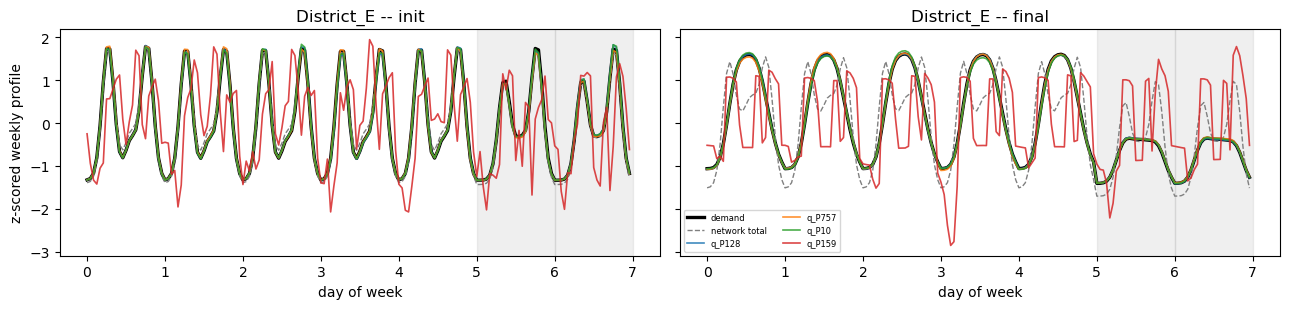

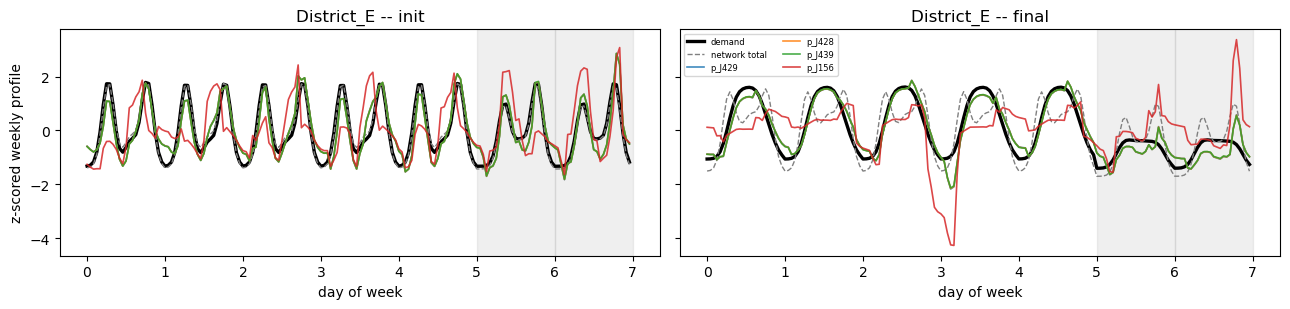

In [12]:
TGT = P.drift["tgt_district"]
fig, axes = plt.subplots(1, 2, figsize=(13, 3.2), sharey=True)
sp.plot_weekly(P, TGT, scores, kind="flow", n=3, axes=axes)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 3.2), sharey=True)
sp.plot_weekly(P, TGT, scores, kind="pressure", n=3, axes=axes)
plt.tight_layout(); plt.show()

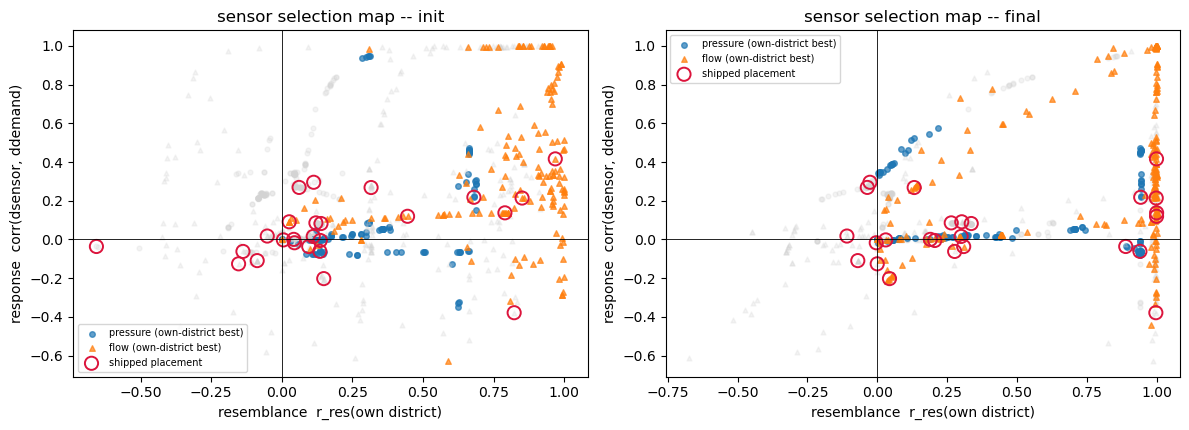

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.4))
sp.plot_selection_map(scores, "init", ax=ax[0])
sp.plot_selection_map(scores, "final", ax=ax[1])
plt.tight_layout(); plt.show()

Resemblance on x, response on y. A gauge that tracks the district's shape perfectly in
both phases but sits at response ≈ 0 is usually dominated by transit flow: it looks like
the district because the district's water passes through it, and it does not move when the
district's *behaviour* changes. A prototype needs the upper right.

## 8. Do the gauges cluster by district at all?

Agglomerative clustering on correlation distance between residualised weekly shapes. Two
ARIs: against districts (the placement question — can a gauge be traced to its client) and
against regimes (the thesis question — is the land-use signature legible). Districts that
share a regime cannot be separated by shape, so a low district-ARI with a high regime-ARI
is the model working, not failing.

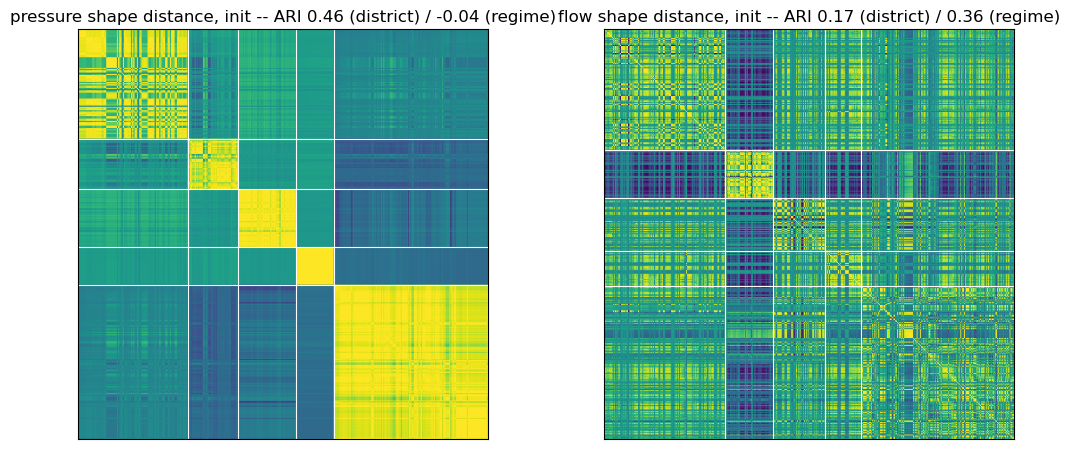

,kind,phase,ari_district,ari_regime,silhouette
0,pressure,init,0.464,-0.037,0.819
1,pressure,final,0.506,0.983,0.752
2,flow,init,0.172,0.362,0.072
3,flow,final,0.253,0.584,-0.017


In [14]:
rows, fig = [], None
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
for ax, kind in zip(axes, ("pressure", "flow")):
    cl = sp.cluster(P, cand, phase="init", kind=kind)
    sp.plot_cluster(cl, ax=ax)
    rows.append({"kind": kind, "phase": "init", "ari_district": cl["ari"],
                 "ari_regime": cl["ari_regime"],
                 "silhouette": cl["silhouette_true_labels"]})
    cl2 = sp.cluster(P, cand, phase="final", kind=kind)
    rows.append({"kind": kind, "phase": "final", "ari_district": cl2["ari"],
                 "ari_regime": cl2["ari_regime"],
                 "silhouette": cl2["silhouette_true_labels"]})
plt.tight_layout(); plt.show()
CLUST = pd.DataFrame(rows).round(3)
CLUST

## 9. Topology against measurement

If `served_own` predicts `r_res_own`, the ranking is explainable from the network alone —
which would make placement transferable to a network that has not been simulated yet.
Where they disagree, the hydraulics are doing something the topology does not say: a loop
the downstream walk over-counts, or (on D-Town) a crossing that is a pump or a valve, where
the direction is set by a control rather than by the gradient.

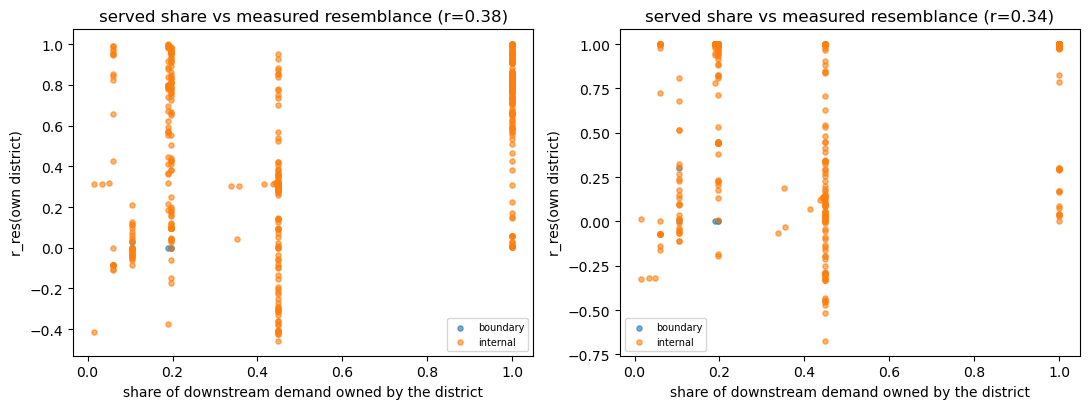

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
sp.plot_served_vs_measured(scores, cand, "init", ax=ax[0])
sp.plot_served_vs_measured(scores, cand, "final", ax=ax[1])
plt.tight_layout(); plt.show()

## 10. Ranking, the shipped placement, and a proposal

In [16]:
display(sp.rank(scores, phase="init", kind="flow", top=3).round(3))
display(sp.rank(scores, phase="init", kind="pressure", top=3).round(3))

,id,kind,district,own_regime,role,shipped,r_raw_own,r_res_own,margin_regime,regime_hit,lag_h,c_weekend,response
0,q_P937,flow,District_A,LR,internal,False,1.000,0.985,1.967,True,0.0,-0.129,0.366
1,q_P951,flow,District_A,LR,internal,False,1.000,0.983,1.962,True,0.0,-0.138,0.329
2,q_P938,flow,District_A,LR,internal,False,1.000,0.983,1.963,True,0.0,-0.137,0.291
3,q_P42,flow,District_B,LI,internal,False,1.000,1.000,1.959,True,0.0,-1.057,0.244
4,q_P633,flow,District_B,LI,internal,False,1.000,1.000,1.958,True,0.0,-1.056,0.323
5,q_P48,flow,District_B,LI,internal,False,1.000,1.000,1.959,True,0.0,-1.063,0.249
6,q_P976,flow,District_C,LR,internal,False,0.999,0.953,1.889,True,0.0,-0.101,0.266
7,q_P781,flow,District_C,LR,internal,False,0.999,0.947,1.872,True,0.0,-0.154,0.328
8,q_P981,flow,District_C,LR,internal,False,0.999,0.925,1.834,True,0.0,-0.089,0.298
9,q_P783,flow,District_D,LR,internal,False,1.000,0.991,1.944,True,0.0,-0.128,0.909


,id,kind,district,own_regime,role,shipped,r_raw_own,r_res_own,margin_regime,regime_hit,lag_h,c_weekend,response
0,p_J81,pressure,District_A,LR,internal,False,0.973,0.687,1.353,True,0.0,-0.149,0.152
1,p_J34,pressure,District_A,LR,internal,False,0.973,0.687,1.353,True,0.0,-0.149,0.305
2,p_J38,pressure,District_A,LR,internal,False,0.973,0.686,1.352,True,0.0,-0.151,0.285
3,p_J76,pressure,District_B,LI,internal,False,0.689,0.662,1.296,True,2.0,-0.808,-0.061
4,p_J92,pressure,District_B,LI,internal,False,0.687,0.659,1.291,True,2.0,-0.806,-0.061
5,p_J70,pressure,District_B,LI,internal,False,0.660,0.631,1.237,True,2.0,-0.783,-0.062
6,p_J297,pressure,District_C,LR,internal,False,0.767,0.122,0.243,True,0.0,-0.082,0.047
7,p_J439,pressure,District_E,LR,internal,False,0.885,0.314,0.627,True,0.0,-0.125,0.950
8,p_J428,pressure,District_E,LR,internal,False,0.882,0.308,0.615,True,0.0,-0.128,0.948
9,p_J429,pressure,District_E,LR,internal,False,0.880,0.304,0.607,True,0.0,-0.128,0.947


In [17]:
# Where the bundle's own rule (largest base demand / highest elevation / largest mean
# |flow|) lands in the candidate ranking. `pct` is a percentile within (district, kind).
# The rule was never chosen to maximise shape resemblance, so a low percentile is
# information about the rule, not a bug.
sp.compare_to_shipped(scores, "init").round(3)

,id,kind,district,role,r_res_own,margin_regime,regime_hit,response,pct
0,q_P1036,flow,District_A,internal,0.969,1.919,True,0.416,0.963
1,q_P349,flow,District_A,internal,0.006,0.011,True,-0.002,0.059
2,q_P958,flow,District_A,internal,0.823,1.636,True,-0.379,0.696
3,p_J32,pressure,District_A,internal,0.680,1.341,True,0.218,0.925
4,p_J497,pressure,District_A,internal,0.136,0.268,True,-0.005,0.344
5,q_P1044,flow,District_B,internal,-0.153,-0.319,False,-0.126,0.037
6,q_P245,flow,District_B,internal,0.790,1.534,True,0.138,0.463
7,q_P842,flow,District_B,internal,0.445,0.849,True,0.120,0.222
8,p_J67,pressure,District_B,internal,0.135,0.258,True,-0.061,0.535
9,p_J87,pressure,District_B,internal,-0.656,-1.318,False,-0.036,0.023


In [18]:
SEL = sp.select(scores, phase="init", n_pressure=2, n_flow=3, min_response=0.0)
print(sp.sensors_yaml(SEL))

select: no candidate passed the filters for District_B/pressure, District_D/pressure -- fell back to the best available
sensors:
  District_A: {pressure: ["J81", "J34"], flow: ["P937", "P951", "P938"]}
  District_B: {pressure: ["J76", "J92"], flow: ["P42", "P633", "P48"]}
  District_C: {pressure: ["J297"], flow: ["P976", "P781", "P981"]}
  District_D: {pressure: ["J123", "J145"], flow: ["P783", "P786", "P795"]}
  District_E: {pressure: ["J439", "J428"], flow: ["P10", "P757", "P128"]}


`select` gates on resemblance **and** on response, and refuses to return an empty channel:
a district with no passing pressure candidate falls back to the best available and says so,
because a client CSV missing a whole kind gives `preprocess_clients` a different feature
geometry per client.

## 11. Persist the analysis tables

In [19]:
# ana = path / "analysis"
# ana.mkdir(exist_ok=True)
# cand.to_parquet(ana / "candidates.parquet", index=False)
# scores.to_parquet(ana / "scores.parquet", index=False)
# sp.phase_delta(P).to_csv(ana / "phase_delta.csv", index=False)
# sp.discriminative_gap(scores).to_csv(ana / "discriminative_gap.csv", index=False)
# sp.template_fit(P).to_csv(ana / "template_fit.csv", index=False)
# CLUST.to_csv(ana / "cluster.csv", index=False)
# (ana / "sensors_proposed.yml").write_text(sp.sensors_yaml(SEL))
# print(sorted(p.name for p in ana.iterdir()))

## 12. Cross-network contrast

The same configuration on both networks. KY7 is pipes-and-tanks with nine pipe crossings;
D-Town is pumps and valves at seven of its eight crossings. If a conclusion holds on one
and not the other, it is a property of the network, not of the method — which is exactly
the failure mode the Graeme-only results had.

Costs one more solve. Skip it while iterating on a single network.

In [20]:
# RUN_BOTH = True

# summaries, gaps, clusters = [], [], []
# if RUN_BOTH:
#     for name, cfg in CFGS.items():
#         w = world if name == NETWORK else lw.build(cfg, ROOT, verbose=False)
#         p_ = lw.persist(w, OUT)
#         Pi = sp.from_world(w)
#         ci = sp.candidates(Pi)
#         si = sp.battery(Pi, ci)
#         summaries.append(lw.summary(w))
#         gaps.append(sp.discriminative_gap(si).assign(network=name))
#         for kind in ("pressure", "flow"):
#             cl = sp.cluster(Pi, ci, phase="init", kind=kind)
#             clusters.append({"network": name, "kind": kind,
#                              "ari_district": cl["ari"], "ari_regime": cl["ari_regime"]})
#         si.to_parquet(p_ / "scores.parquet", index=False)

#     display(pd.DataFrame(summaries).set_index("network"))
#     display(pd.concat(gaps).set_index(["network", "phase", "kind"]).round(3))
#     display(pd.DataFrame(clusters).round(3))

## 13. Read-out

Fill in from the run above.

**Did the drift reach an observable.** `phase_delta`: `shape_shift` on the target district
against `d_pressure` and `d_boundary_%`. If the shape moved and neither channel did, stop
here — the placement question is moot and the drift needs a larger `beta` or a different
target district.

**Which channel discriminates.** `gap_regime` by kind. Graeme's numbers were ~0.004
(pressure) against ~0.23 (flow). If pressure is comparable to flow on a tank-heavy network,
that is new and contradicts the Graeme finding rather than confirming it.

**Whether the signature is legible.** `ari_regime` against `ari_district`. High regime-ARI
with low district-ARI is the expected shape: land use is visible, district identity is not,
because two districts sharing a regime are the same object to a shape metric.

**Lag.** Zero-lag share by kind. Graeme gave 0 everywhere at every resolution, which is why
every directional test returned null or artifact. A non-zero lag here is a mechanism, and
the first thing to check is whether it tracks the tanks.

**Topology vs measurement.** The `served_own` correlation in §9. A high value makes
placement transferable without simulating first; a low one means placement has to be
measured per world.

**The shipped placement.** Its percentile in §10. Low is expected — the rule optimises
demand magnitude and elevation, not shape resemblance — but *how* low decides whether the
existing corpus of FL results was run on gauges that could carry the signal at all.

### Next
Once this reads cleanly on both networks, fabricate the multi-mapping version: hold the
network fixed, sweep `map_code` and `to_land_use`, and ask whether the selected sensor set
is stable across mappings or has to be re-derived per world. That stability is what decides
whether sensor placement is a property of the network or of the scenario.